# XSIGHT Lung Sound Classifier — Colab Training Notebook

Trains a 1D-CNN to predict one of 4 labels on the **ICBHI 2017 Respiratory
Sound Database**:

`normal | crackle | wheeze | both`

**Why 4 classes, not 5:** the backend's placeholder heuristic
(`server/app/lung_classifier.py`) currently lists
`normal, wheeze, crackle, rhonchi, diminished`, but no public dataset labels
rhonchi or diminished breath sounds as a separate class — ICBHI (the
standard benchmark for this task) only labels **crackle**, **wheeze**,
**both** (simultaneous), and **normal**. Training on real data means
adopting ICBHI's 4-class scheme. `rhonchi`/`diminished` will need to be
dropped or re-added later via a different dataset/heuristic — see
`LUNG_TRAINING.md` at the repo root for the follow-up plan.

**Realistic accuracy expectation:** with *patient-aware* evaluation (no
patient's clips split across train/val/test — see §7), published ICBHI
results land around **55-72% accuracy** on this 4-class problem, not the
90%+ you'll see in papers that leak patient identity across splits. This
notebook uses `GroupShuffleSplit` on patient ID to avoid that leakage, so
expect numbers in that realistic range, not near-perfect ones.

Outputs:
- `lung_model.pt` — PyTorch state_dict, architecture matches
  `LungNet` already defined in `server/app/lung_classifier.py`
- `labels.json` — label list (index → string)
- `metrics.json` — per-class precision/recall/AUROC, confusion matrix,
  patient-aware split sizes
- `confusion.png` — confusion matrix heatmap

Drop `lung_model.pt` into `server/app/lung_model.pt` on the XSIGHT backend
and restart `python main.py` — `lung_classifier.py` auto-prefers the torch
model over the heuristic fallback once the file exists, no code changes
needed.

## 1. Setup

In [2]:
!pip install -q torch torchaudio scikit-learn pandas matplotlib kagglehub tqdm scipy
import torch, torch.nn as nn, torch.optim as optim, json, os, struct
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt, resample_poly
from math import gcd
from pathlib import Path

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', DEVICE, '| torch =', torch.__version__)

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=True)
    OUT = Path('/content/drive/MyDrive/lung_sound')
    DATA_ROOT = Path('/content/data')
else:
    OUT = Path('./xsight_lung_output').resolve()
    DATA_ROOT = Path('./data').resolve()

print(f'Running in Colab: {IN_COLAB}')
OUT.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive
Running in Colab: True


## 2. Download ICBHI 2017 Respiratory Sound Database

Requires a Kaggle account. Uses the same credential flow as
`xray_train.ipynb` — paste a token below, or rely on credentials already
saved in Drive (`MyDrive/lung_sound/kaggle.json`) or the local `~/.kaggle/kaggle.json`.

Dataset mirror on Kaggle:
`nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database` (~2 GB — 920 `.wav` + `.txt`
annotation pairs from 126 patients, plus `patient_diagnosis.csv` and a
train/test split file).

In [3]:
from pathlib import Path
import shutil

KAGGLE_DIR = Path.home() / '.kaggle'
KAGGLE_JSON_DEST = KAGGLE_DIR / 'kaggle.json'

if not KAGGLE_JSON_DEST.exists():
    KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
    drive_json = Path('/content/drive/MyDrive/lung_sound/kaggle.json')
    if drive_json.exists():
        shutil.copy(drive_json, KAGGLE_JSON_DEST)
        KAGGLE_JSON_DEST.chmod(0o600)
        print(f'Loaded kaggle.json from {drive_json}')
    else:
        print('WARNING: kaggle.json not found at', drive_json)
else:
    print('Kaggle credentials already present.')

Kaggle credentials already present.


In [4]:
from pathlib import Path
import shutil

if 'DATA_ROOT' not in dir():
    DATA_ROOT = Path('./data').resolve()
    print('WARNING: Setup cell not run — using local ./data. Re-run Setup for Colab paths.')

ICBHI_DIR = DATA_ROOT / 'icbhi'

if ICBHI_DIR.exists() and not any(ICBHI_DIR.iterdir()):
    shutil.rmtree(ICBHI_DIR)

if not ICBHI_DIR.exists():
    print('Downloading ICBHI 2017 Respiratory Sound Database from Kaggle...')
    import kagglehub
    src = Path(kagglehub.dataset_download('nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database'))
    ICBHI_DIR.mkdir(parents=True, exist_ok=True)
    for item in src.rglob('*'):
        if item.is_file():
            dest = ICBHI_DIR / item.relative_to(src)
            dest.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy(item, dest)
    print('Done.')
else:
    print('ICBHI already present at', ICBHI_DIR)

# Kaggle mirrors vary: recordings may be in audio_and_txt_files or directly
# in a nested extracted folder. Use the directory containing the most WAVs.
audio_dirs = [path for path in ICBHI_DIR.rglob('*') if path.is_dir() and any(path.glob('*.wav'))]
AUDIO_DIR = max(audio_dirs, key=lambda path: len(list(path.glob('*.wav'))), default=None)
DIAG_CSV = next(ICBHI_DIR.rglob('patient_diagnosis.csv'), None)
print('AUDIO_DIR =', AUDIO_DIR)
print('DIAG_CSV  =', DIAG_CSV)
assert AUDIO_DIR is not None, f'No .wav files found under {ICBHI_DIR}. Delete it and rerun after confirming Kaggle download access.'

ICBHI already present at /content/data/icbhi
AUDIO_DIR = /content/data/icbhi/ICBHI_final_database
DIAG_CSV  = None


## 3. Parse annotations into a cycle-level manifest

Each recording has a matching `.txt` file with one row per respiratory
cycle: `start_sec  end_sec  has_crackle(0/1)  has_wheeze(0/1)`. We slice
each cycle out of its `.wav`, label it `normal / crackle / wheeze / both`,
and record the **patient ID** (parsed from the filename, e.g.
`101_1b1_Al_sc_Meditron.wav` → patient `101`) so the split in §7 can group
by patient and avoid leakage.

In [5]:
from pathlib import Path
import pandas as pd

if 'AUDIO_DIR' not in dir() or AUDIO_DIR is None:
    AUDIO_DIR = next(Path('./data').resolve().rglob('audio_and_txt_files'), None)
    if AUDIO_DIR is None:
        raise SystemExit('Run the Download cell first, or place the ICBHI dataset under ./data.')
    print('WARNING: Download cell not run — found audio files at', AUDIO_DIR)

def parse_patient_id(wav_path: Path) -> str:
    return wav_path.stem.split('_')[0]

def label_for(has_crackle: int, has_wheeze: int) -> str:
    if has_crackle and has_wheeze:
        return 'both'
    if has_crackle:
        return 'crackle'
    if has_wheeze:
        return 'wheeze'
    return 'normal'

LABELS = ['normal', 'crackle', 'wheeze', 'both']
LABEL_TO_IDX = {l: i for i, l in enumerate(LABELS)}

rows = []
wav_files = sorted(AUDIO_DIR.glob('*.wav'))
print(f'found {len(wav_files)} recordings')

for wav_path in wav_files:
    txt_path = wav_path.with_suffix('.txt')
    if not txt_path.exists():
        continue
    patient_id = parse_patient_id(wav_path)
    with open(txt_path) as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) != 4:
                continue
            start, end, crackle, wheeze = parts
            rows.append({
                'wav_path': str(wav_path),
                'start': float(start),
                'end': float(end),
                'label': label_for(int(crackle), int(wheeze)),
                'patient_id': patient_id,
            })

df = pd.DataFrame(rows)
df['y'] = df['label'].map(LABEL_TO_IDX)
print(f'total respiratory cycles: {len(df)}')
print(df['label'].value_counts())
print(f'unique patients: {df["patient_id"].nunique()}')

found 920 recordings
total respiratory cycles: 6898
label
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64
unique patients: 126


## 4. Audio loading + preprocessing — matches `lung_classifier.py`

Mirrors the backend preprocessing pipeline:
1. Parse WAV PCM16/32, downmix to mono
2. Resample to 16kHz using scipy.signal.resample_poly
3. Bandpass filter 50-2000 Hz (Butterworth)
4. DC offset removal + peak normalization

This ensures training and inference see identical signal conditioning.

In [6]:
import struct
import numpy as np
from scipy.signal import butter, sosfilt, resample_poly
from math import gcd
from pathlib import Path

_SAMPLE_RATE = 16000

def wav_to_pcm16(raw: bytes) -> np.ndarray:
    """Mirrors server/app/lung_classifier.py::_wav_to_pcm16 exactly."""
    try:
        if raw[:4] != b'RIFF':
            return np.frombuffer(raw, dtype=np.int16).astype(np.float32) / 32768.0
        channels = struct.unpack_from('<H', raw, 22)[0]
        sr = struct.unpack_from('<I', raw, 24)[0]
        bits = struct.unpack_from('<H', raw, 34)[0]
        data_offset = raw.find(b'data') + 8
        pcm = raw[data_offset:]
        if bits == 16:
            samples = np.frombuffer(pcm, dtype=np.int16).astype(np.float32) / 32768.0
        elif bits == 32:
            samples = np.frombuffer(pcm, dtype=np.int32).astype(np.float32) / 2147483648.0
        else:
            samples = np.frombuffer(pcm, dtype=np.int16).astype(np.float32) / 32768.0
        if channels > 1:
            samples = samples[::channels]
        if sr != _SAMPLE_RATE:
            g = gcd(sr, _SAMPLE_RATE)
            samples = resample_poly(samples, _SAMPLE_RATE // g, sr // g).astype(np.float32)
        return samples
    except Exception:
        return np.frombuffer(raw, dtype=np.int16).astype(np.float32) / 32768.0

def bandpass(samples, low=50.0, high=2000.0, sr=_SAMPLE_RATE, order=4):
    """Butterworth bandpass filter matching lung_classifier.py."""
    nyq = sr / 2.0
    sos = butter(order, [low / nyq, min(high / nyq, 0.999)], btype='band', output='sos')
    return sosfilt(sos, samples).astype(np.float32)

def preprocess(samples):
    """Full preprocessing pipeline matching lung_classifier.py."""
    samples = bandpass(samples)
    samples = samples - np.mean(samples)  # DC offset removal
    peak = np.abs(samples).max()
    if peak > 1e-8:
        samples = samples / peak
    return samples

def load_cycle(wav_path: str, start: float, end: float) -> np.ndarray:
    """Loads one respiratory cycle, preprocessed, as a float32 array."""
    with open(wav_path, 'rb') as f:
        raw = f.read()
    full = wav_to_pcm16(raw)
    s = int(start * _SAMPLE_RATE)
    e = int(end * _SAMPLE_RATE)
    cycle = full[s:e]
    return preprocess(cycle)

## 5. Preview a few cycles per class to confirm parsing

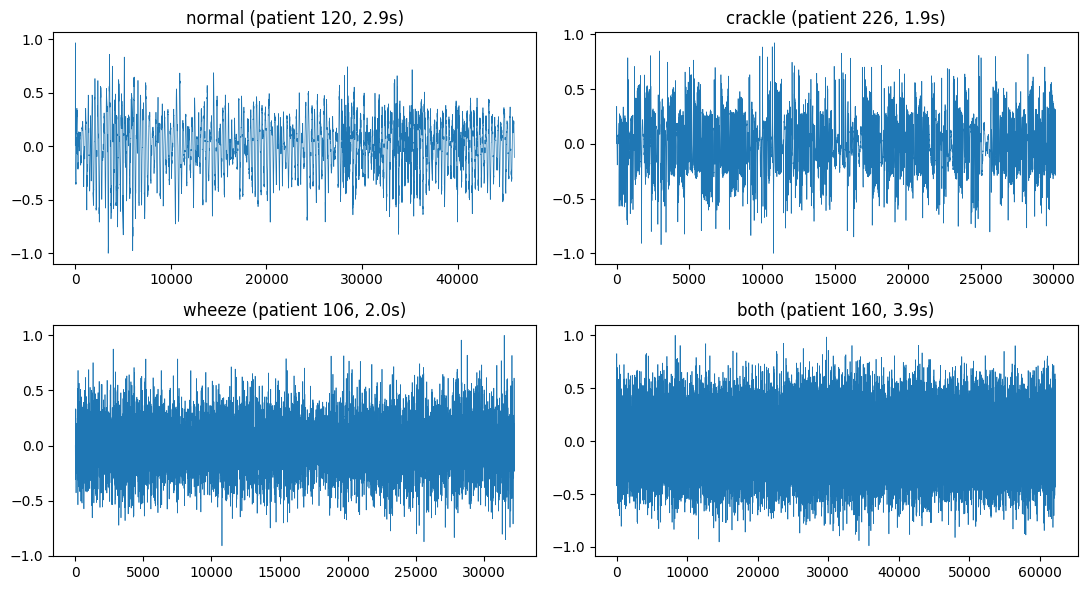

In [7]:
import matplotlib.pyplot as plt

assert 'LABELS' in dir() and 'df' in dir() and 'load_cycle' in dir(), \
    'Run cells 3-6 first (Setup → Download → Parse → Audio loading) before this cell.'

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, label in zip(axes.flat, LABELS):
    subset = df[df['label'] == label]
    if len(subset) == 0:
        ax.set_title(f'{label} (no sample)')
        ax.axis('off')
        continue
    row = subset.sample(1, random_state=0).iloc[0]
    samples = load_cycle(row['wav_path'], row['start'], row['end'])
    ax.plot(samples, linewidth=0.5)
    ax.set_title(f"{label} (patient {row['patient_id']}, {row['end']-row['start']:.1f}s)")
plt.tight_layout()
plt.show()

## 6. Mel-spectrogram dataset

Converts each respiratory cycle to a **log-mel spectrogram** (64 mel bins,
128 time frames) — the same representation used at inference time in
`lung_classifier.py::_log_mel_spectrogram`. This captures frequency
patterns (crackle bursts, wheeze harmonics) much better than raw waveform
CNNs. Includes Mixup and SpecAugment augmentation for training.

In [8]:
import torch
import numpy as np

_WINDOW = _SAMPLE_RATE * 4  # 64000 samples = 4s
_N_MELS = 64
_N_FFT = 512
_HOP = 256
_N_TIME = 128

def mel_filterbank(n_fft, n_mels, sr=_SAMPLE_RATE, fmin=50.0, fmax=2000.0):
    """Create mel-scale triangular filterbank (n_mels, n_fft//2+1)."""
    def hz_to_mel(f): return 2595.0 * np.log10(1.0 + f / 700.0)
    def mel_to_hz(m): return 700.0 * (10.0 ** (m / 2595.0) - 1.0)
    mel_points = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bin_points = np.floor((n_fft + 1) * hz_points / sr).astype(int)
    n_freqs = n_fft // 2 + 1
    fb = np.zeros((n_mels, n_freqs), dtype=np.float32)
    for m in range(n_mels):
        left, center, right = bin_points[m], bin_points[m+1], bin_points[m+2]
        for k in range(left, center):
            if center != left: fb[m, k] = (k - left) / (center - left)
        for k in range(center, right):
            if right != center: fb[m, k] = (right - k) / (right - center)
    return fb

_MEL_FB = mel_filterbank(_N_FFT, _N_MELS)
_WINDOW_ARR = np.hanning(_N_FFT).astype(np.float32)

def log_mel_spectrogram(samples, n_mels=_N_MELS, n_fft=_N_FFT,
                        hop=_HOP, n_time=_N_TIME):
    """Vectorized log-mel spectrogram (no Python for-loop)."""
    n_frames = max(1, 1 + (len(samples) - n_fft) // hop)
    # Stride trick: build all frames at once without a loop
    shape = (n_frames, n_fft)
    strides = (samples.strides[0] * hop, samples.strides[0])
    frames = np.lib.stride_tricks.as_strided(samples, shape=shape, strides=strides)
    frames = (frames * _WINDOW_ARR).copy()  # (n_frames, n_fft)
    mag = np.abs(np.fft.rfft(frames, axis=1))  # (n_frames, n_freqs)
    mel = (mag @ _MEL_FB.T).astype(np.float32)  # (n_frames, n_mels)
    mel = np.log10(mel + 1e-10)
    # Transpose to (n_mels, n_frames) then pad/truncate time axis
    mel = mel.T
    if mel.shape[1] < n_time:
        mel = np.pad(mel, ((0, 0), (0, n_time - mel.shape[1])))
    else:
        mel = mel[:, :n_time]
    mn, mx = mel.min(), mel.max()
    if mx - mn > 1e-8:
        mel = (mel - mn) / (mx - mn)
    return mel

class LungCycleDS(torch.utils.data.Dataset):
    def __init__(self, frame, augment=False):
        self.frame = frame.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        samples = load_cycle(row['wav_path'], row['start'], row['end'])

        # Pad/truncate to window
        if len(samples) < _WINDOW:
            samples = np.pad(samples, (0, _WINDOW - len(samples)))
        else:
            samples = samples[:_WINDOW]

        # Augment on raw waveform before spectrogram
        if self.augment:
            samples = samples * np.random.uniform(0.85, 1.15)
            samples = samples + np.random.normal(0, 0.005, samples.shape).astype(np.float32)

        spec = log_mel_spectrogram(samples)  # (n_mels, n_time)

        # SpecAugment: mask random time and frequency bands
        if self.augment:
            tw = np.random.randint(0, max(1, _N_TIME // 8))
            t0 = np.random.randint(0, max(1, _N_TIME - tw))
            spec[:, t0:t0+tw] = 0
            fw = np.random.randint(0, max(1, _N_MELS // 8))
            f0 = np.random.randint(0, max(1, _N_MELS - fw))
            spec[f0:f0+fw, :] = 0

        return torch.from_numpy(spec).unsqueeze(0), int(row['y'])  # (1, n_mels, n_time)

## 7. Patient-aware train/val/test split (65/15/20)

**This is the most important cell in the notebook.** `GroupShuffleSplit`
on `patient_id` guarantees no patient's respiratory cycles appear in more
than one split — a patient's cough, chest wall, and recording-channel
characteristics leak across their own cycles, so a random cycle-level split
would let the model partly memorize per-patient acoustic fingerprints
instead of learning genuinely generalizable crackle/wheeze features. This
is exactly the caveat flagged for ICBHI results in the wild — accuracy
numbers built on a naive random split are not comparable to these.

In [9]:
from sklearn.model_selection import GroupShuffleSplit

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.35, random_state=42)
train_idx, rest_idx = next(gss1.split(df, groups=df['patient_id']))
tr = df.iloc[train_idx]
rest = df.iloc[rest_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=(0.20/0.35), random_state=42)
val_idx, test_idx = next(gss2.split(rest, groups=rest['patient_id']))
va = rest.iloc[val_idx]
te = rest.iloc[test_idx]

print(f'train={len(tr)} ({tr["patient_id"].nunique()} patients)')
print(f'val={len(va)} ({va["patient_id"].nunique()} patients)')
print(f'test={len(te)} ({te["patient_id"].nunique()} patients)')
assert set(tr['patient_id']) & set(va['patient_id']) == set()
assert set(tr['patient_id']) & set(te['patient_id']) == set()
assert set(va['patient_id']) & set(te['patient_id']) == set()
print('no patient overlap across splits — confirmed')
print()
print('train label distribution:')
print(tr['label'].value_counts())

train=4620 (81 patients)
val=960 (19 patients)
test=1318 (26 patients)
no patient overlap across splits — confirmed

train label distribution:
label
normal     2372
crackle    1272
wheeze      639
both        337
Name: count, dtype: int64


## 8. Model — `LungNet2D`, mel-spectrogram CNN matching `lung_classifier.py`

This is a **verbatim copy** of the `LungNet2D` class inside
`server/app/lung_classifier.py::load()`. The2D convolutional architecture
processes log-mel spectrograms (1, n_mels, n_time) instead of raw waveforms,
capturing frequency patterns like crackle bursts and wheeze harmonics much
more effectively. Keep this identical to the backend or `load_state_dict`
will silently skip mismatched layers.

In [10]:
import torch
import torch.nn as nn

if 'LABELS' not in dir():
    LABELS = ['normal', 'crackle', 'wheeze', 'both']
if 'DEVICE' not in dir():
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

class LungNet2D(nn.Module):
    """Compact 2D CNN for log-mel spectrogram classification.
    Input:  (batch, 1, n_mels, n_time)
    Output: (batch, num_classes)
    """
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = LungNet2D(num_classes=len(LABELS)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'params: {n_params:.2f} M')

params: 0.10 M


## 9. Train loop (focal loss + class-balanced sampling)

Uses **focal loss** (Lin et al. 2017) instead of plain CrossEntropy — focal
loss down-weights easy examples and focuses training on hard cases, which
helps significantly with the class imbalance in ICBHI (~53% normal, ~7%
both). Combined with WeightedRandomSampler for balanced class exposure.

In [11]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm
from pathlib import Path

if not {'tr', 'va', 'te', 'LABELS', 'LungCycleDS', 'model', 'DEVICE'}.issubset(globals()):
    raise SystemExit('Runtime was reset. Run Setup, Download, Parse annotations, Audio loading, Mel-spectrogram, Split, then Model cells before training.')

# Self-contained fallback: if the Setup cell wasn't run, OUT isn't defined.
if 'OUT' not in dir():
    try:
        from google.colab import drive  # noqa: F401
        _in_colab = True
    except ImportError:
        _in_colab = False
    OUT = Path('/content/drive/MyDrive/lung_sound') if _in_colab else Path('./xsight_lung_output').resolve()
    OUT.mkdir(parents=True, exist_ok=True)
    print('WARNING: Setup cell not run — using fallback OUT =', OUT)

BS = 128
EPOCHS = 5
NUM_WORKERS = 4

class FocalLoss(nn.Module):
    """Focal loss for multi-class classification (Lin et al. 2017)."""
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, reduction='none')
        return (((1 - torch.exp(-ce)) ** self.gamma) * ce).mean()

class_counts = tr['y'].value_counts().sort_index().reindex(range(len(LABELS)), fill_value=1)
sample_weights = tr['y'].map(1.0 / class_counts.clip(lower=1)).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(tr), replacement=True)

tr_ld = DataLoader(LungCycleDS(tr, augment=True), batch_size=BS, sampler=sampler,
                    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True,
                    prefetch_factor=2)
va_ld = DataLoader(LungCycleDS(va, augment=False), batch_size=BS, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True,
                    prefetch_factor=2)
te_ld = DataLoader(LungCycleDS(te, augment=False), batch_size=BS, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True,
                    prefetch_factor=2)

criterion = FocalLoss(gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_acc = 0.0
for epoch in range(EPOCHS):
    model.train()
    pbar = tqdm(tr_ld, desc=f'Epoch {epoch+1}/{EPOCHS}')
    for x, y in pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

        # Mixup augmentation
        if np.random.random() < 0.5:
            lam = np.random.beta(0.2, 0.2)
            idx = torch.randperm(x.size(0), device=x.device)
            x = lam * x + (1 - lam) * x[idx]
            y_a, y_b = y, y[idx]
            logits = model(x)
            loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
        else:
            logits = model(x)
            loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        pbar.set_postfix(loss=f'{loss.item():.3f}')
    scheduler.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in va_ld:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += len(y)
    val_acc = correct / max(total, 1)
    print(f'epoch {epoch+1}: val_acc={val_acc:.3f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), OUT / 'lung_model.pt')
        print(f'  saved new best ({val_acc:.3f})')

print('best val acc:', best_val_acc)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/5:   0%|          | 0/37 [00:00<?, ?it/s]

epoch 1: val_acc=0.330
  saved new best (0.330)


Epoch 2/5:   0%|          | 0/37 [00:00<?, ?it/s]

epoch 2: val_acc=0.391
  saved new best (0.391)


...

epoch 3: val_acc=0.334


Epoch 4/5:   0%|          | 0/37 [00:00<?, ?it/s]

epoch 4: val_acc=0.208


Epoch 5/5:   0%|          | 0/37 [00:00<?, ?it/s]

epoch 5: val_acc=0.285
best val acc: 0.390625


## 10. Temperature calibration

Same post-hoc calibration approach as `xray_train.ipynb` §11 (Guo et al.
2017) — fits a scalar `T` on validation logits to soften overconfident
softmax without touching accuracy. Not currently read by
`lung_classifier.py` at inference time (only the X-ray path applies
`_temperature`), but saved to `metrics.json` in case that's wired up as a
follow-up.

In [15]:
import torch, torch.nn as nn, torch.optim as optim

if 'model' not in dir() or 'va_ld' not in dir():
    raise SystemExit('Run cells 8-9 (Model + Train) first.')

model.load_state_dict(torch.load(OUT / 'lung_model.pt', map_location=DEVICE))
model.eval()

val_logits, val_ys = [], []
with torch.no_grad():
    for x, y in va_ld:
        x = x.to(DEVICE)
        val_logits.append(model(x).cpu())
        val_ys.append(y)
val_logits = torch.cat(val_logits)
val_ys = torch.cat(val_ys)

temperature = torch.nn.Parameter(torch.ones(1) * 1.5)
nll = nn.CrossEntropyLoss()
opt_t = optim.LBFGS([temperature], lr=0.01, max_iter=50)

def _closure():
    opt_t.zero_grad()
    loss = nll(val_logits / temperature, val_ys)
    loss.backward()
    return loss

opt_t.step(_closure)

fitted_temperature = max(float(temperature.detach().item()), 1e-2)
print(f'fitted temperature = {fitted_temperature:.3f}')

fitted temperature = 1.486


## 11. Test metrics + confusion matrix

Reports per-class precision/recall/F1/AUROC on the held-out **patient-aware
test split**, plus a confusion matrix. Given the ICBHI literature ceiling,
expect accuracy in the ~50-65% range — treat anything dramatically higher
as a sign the patient-aware split (§7) leaked somehow, not as a genuine
result.

              precision    recall  f1-score   support

      normal       0.75      0.18      0.29       824
     crackle       0.25      0.51      0.33       261
      wheeze       0.09      0.26      0.13       152
        both       0.07      0.14      0.09        81

    accuracy                           0.25      1318
   macro avg       0.29      0.27      0.21      1318
weighted avg       0.53      0.25      0.27      1318

AUROC (macro): 0.4999749653168549
accuracy=0.250  macro_f1=0.212


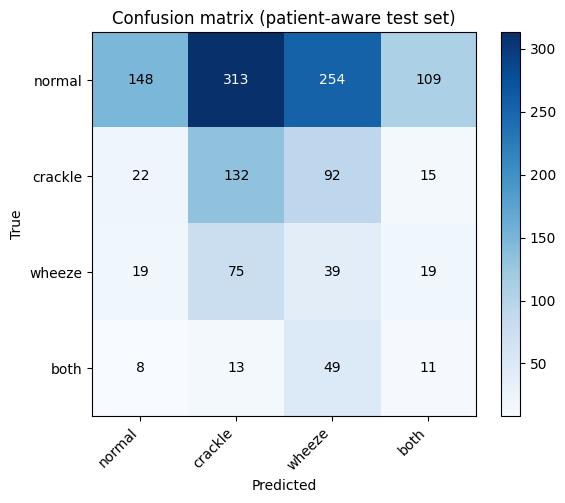

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

if 'te_ld' not in dir() or 'model' not in dir() or 'fitted_temperature' not in dir():
    raise SystemExit('Run cells 7-10 first (Split → Model → Train → Calibration).')

ys, probs = [], []
with torch.no_grad():
    for x, y in te_ld:
        x = x.to(DEVICE)
        logits = model(x).cpu() / fitted_temperature
        p = torch.softmax(logits, dim=1).numpy()
        probs.append(p)
        ys.append(y.numpy())
ys = np.concatenate(ys)
probs = np.concatenate(probs)
preds = probs.argmax(1)

report = classification_report(ys, preds, target_names=LABELS, output_dict=True, zero_division=0)
print(classification_report(ys, preds, target_names=LABELS, zero_division=0))

try:
    auroc = roc_auc_score(ys, probs, multi_class='ovr')
except Exception as e:
    auroc = None
    print('AUROC unavailable:', e)
print('AUROC (macro):', auroc)

cm = confusion_matrix(ys, preds, labels=range(len(LABELS)))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha='right')
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion matrix (patient-aware test set)')
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()

plt.savefig(OUT / 'confusion.png', dpi=150)

if report['accuracy'] > 0.85:
    print('WARNING: accuracy is suspiciously high for a patient-aware ICBHI split — double-check §7 for leakage.')

print(f'accuracy={report["accuracy"]:.3f}  macro_f1={report["macro avg"]["f1-score"]:.3f}')
plt.show()

## 12. Export

In [14]:
import json

if 'report' not in dir():
    raise SystemExit('Run cell 11 (Test metrics) first.')

metrics = {
    'classification_report': report,
    'auroc_macro': auroc,
    'confusion_matrix': cm.tolist(),
    'temperature': fitted_temperature,
    'train_samples': len(tr),
    'val_samples': len(va),
    'test_samples': len(te),
    'train_patients': int(tr['patient_id'].nunique()),
    'val_patients': int(va['patient_id'].nunique()),
    'test_patients': int(te['patient_id'].nunique()),
    'dataset': 'ICBHI 2017 Respiratory Sound Database (Kaggle: nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database)',
}

with open(OUT / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

with open(OUT / 'labels.json', 'w') as f:
    json.dump(LABELS, f, indent=2)

# Config file for lung_classifier.py (architecture + preprocessing params)
config = {
    'n_mels': _N_MELS,
    'n_time': _N_TIME,
    'n_fft': _N_FFT,
    'hop_length': _HOP,
    'window_sec': 4.0,
    'hop_sec': 2.0,
    'num_classes': len(LABELS),
    'temperature': fitted_temperature,
    'sample_rate': _SAMPLE_RATE,
    'bandpass_low': 50.0,
    'bandpass_high': 2000.0,
}
with open(OUT / 'lung_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('saved:', [p.name for p in OUT.iterdir()])
print('Next step: copy lung_model.pt AND lung_config.json to server/app/')
print('and restart `python main.py`. The new LungNet2D architecture and')
print('mel-spectrogram pipeline will auto-load. Temperature calibration is')
print('now applied at inference time for better confidence estimates.')

saved: ['kaggle.json', 'lung_model.pt', 'confusion.png', 'metrics.json', 'labels.json', 'lung_config.json']
Next step: copy lung_model.pt AND lung_config.json to server/app/
and restart `python main.py`. The new LungNet2D architecture and
mel-spectrogram pipeline will auto-load. Temperature calibration is
now applied at inference time for better confidence estimates.
